In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
gender_file = pd.read_csv(r"C:\Users\SURJIT PATIL\OneDrive\Desktop\Elevate Lab\Day 5th Task\gender_submission.csv")
gender_file


,PassengerId,Survived
0,892,0
1,893,1
2,894,0
3,895,0
4,896,1
...,...,...
413,1305,0
414,1306,1
415,1307,0
416,1308,0


In [9]:
test_data = pd.read_csv(r"C:\Users\SURJIT PATIL\OneDrive\Desktop\Elevate Lab\Day 5th Task\test.csv")
test_data

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...
413,1305,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,NaN,S
414,1306,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C
415,1307,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S
416,1308,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.0500,NaN,S


In [10]:
train_data = pd.read_csv(r"C:\Users\SURJIT PATIL\OneDrive\Desktop\Elevate Lab\Day 5th Task\train.csv")
train_data

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [11]:
# Set styles for plots
sns.set(style="darkgrid")
%matplotlib inline

In [12]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [13]:
train_data.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [17]:
# Value counts for 'Survived' column
train_data['Survived'].value_counts()


Survived
0    549
1    342
Name: count, dtype: int64

In [18]:
train_data['Pclass'].value_counts()

Pclass
3    491
1    216
2    184
Name: count, dtype: int64

In [19]:
train_data['Sex'].value_counts()

Sex
male      577
female    314
Name: count, dtype: int64

In [21]:
# Value counts for a categorical column (Embarked)
print(train_data['Embarked'].value_counts())

Embarked
S    644
C    168
Q     77
Name: count, dtype: int64


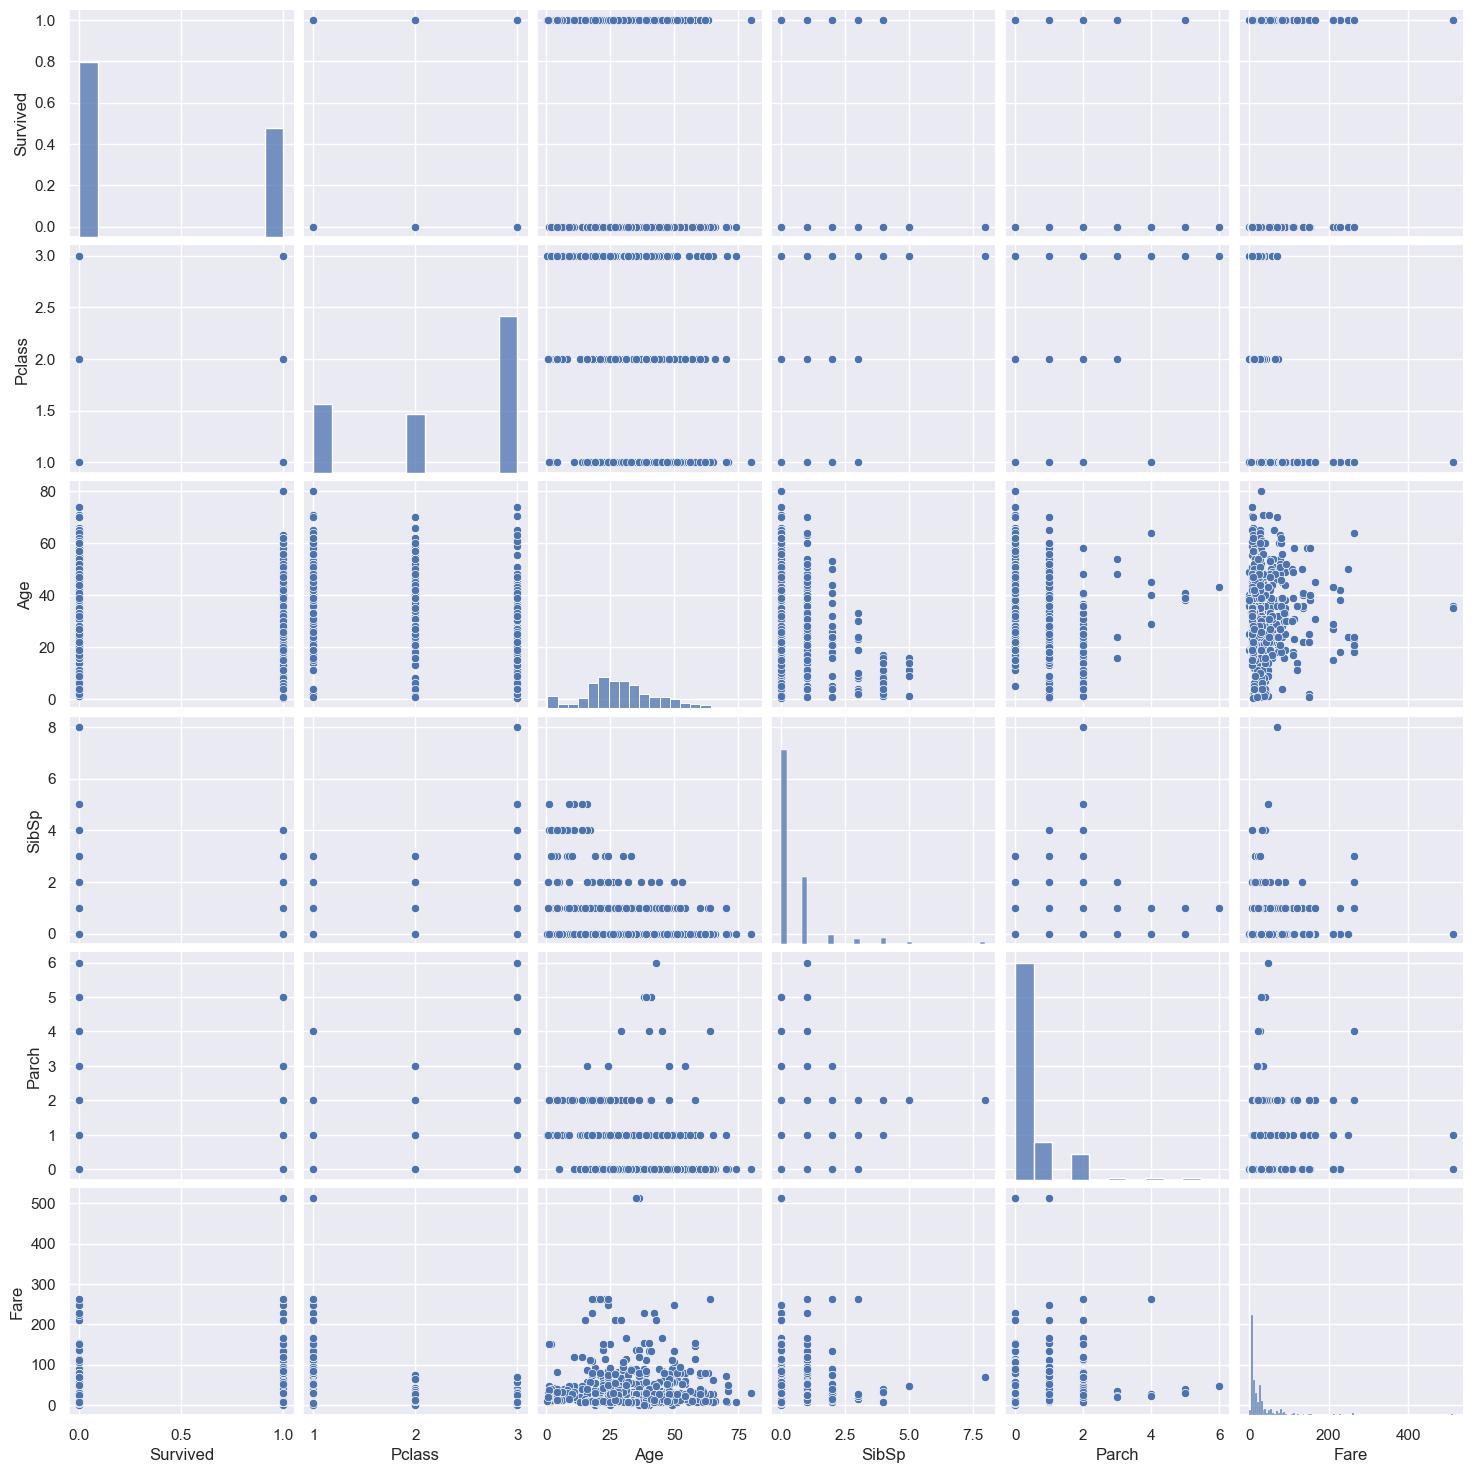

In [24]:
# Pairplot - only use numeric columns to avoid clutter
sns.pairplot(train_data[['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']])
plt.show()

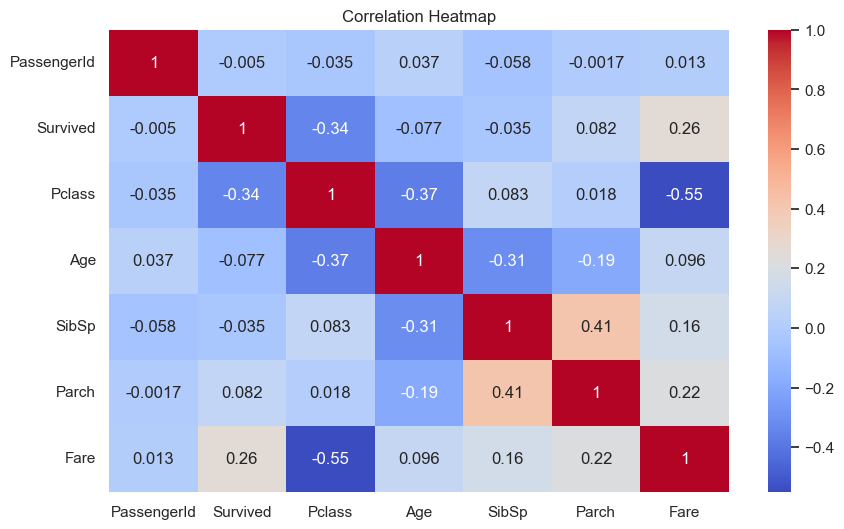

In [28]:
# Heatmap of correlations
plt.figure(figsize=(10,6))
numeric_data = train_data.select_dtypes(include='number')  # Select only numeric columns
sns.heatmap(numeric_data.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

In [29]:
# Survival rate by Pclass
print(train_data.groupby('Pclass')['Survived'].mean())

Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64


In [31]:
# Survival rate by Sex
print(train_data.groupby('Sex')['Survived'].mean())

Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64


In [32]:
# Survival rate by Embarked
print(train_data.groupby('Embarked')['Survived'].mean())

Embarked
C    0.553571
Q    0.389610
S    0.336957
Name: Survived, dtype: float64


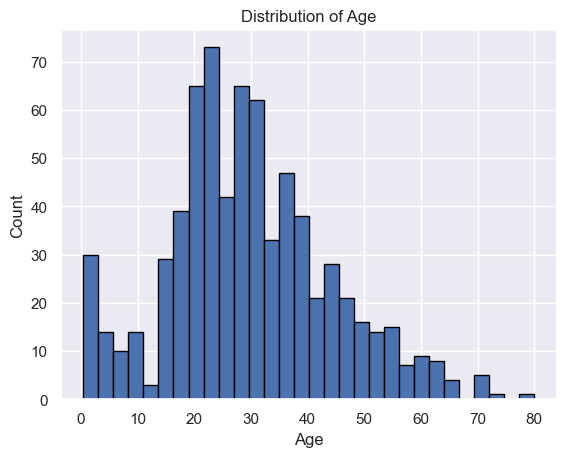

In [33]:
# Histogram of Age
train_data['Age'].hist(bins=30, edgecolor='black')
plt.title('Distribution of Age')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

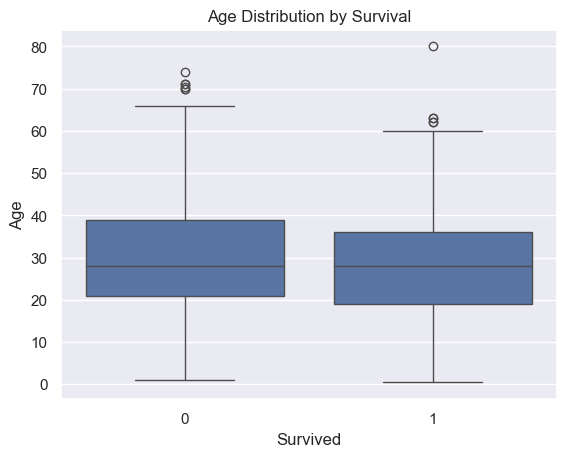

In [34]:
# Boxplot of Age vs Survived
sns.boxplot(x='Survived', y='Age', data=train_data)
plt.title('Age Distribution by Survival')
plt.show()

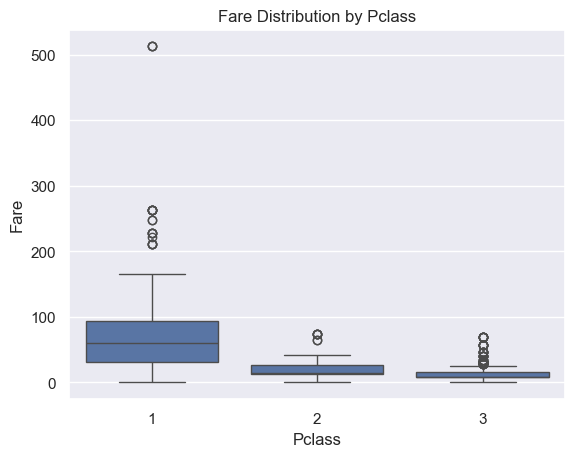

In [35]:
# Boxplot of Fare vs Pclass
sns.boxplot(x='Pclass', y='Fare', data=train_data)
plt.title('Fare Distribution by Pclass')
plt.show()


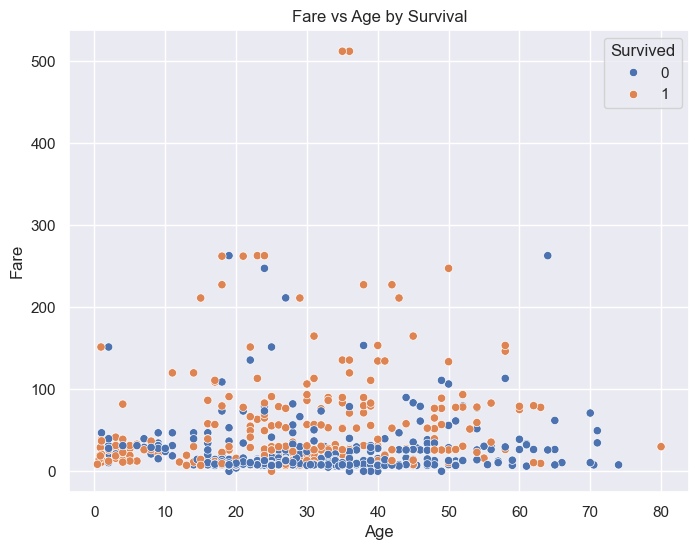

In [36]:
# Scatter plot of Fare vs Age colored by survival
plt.figure(figsize=(8,6))
sns.scatterplot(x='Age', y='Fare', hue='Survived', data=train_data)
plt.title('Fare vs Age by Survival')
plt.show()

In [ ]:
### Observations:
- Age and Fare have skewed distributions with some outliers.
- Higher-class passengers (Pclass 1) had higher survival rates.
- Females had significantly higher survival chances.
- Some correlation exists between Fare and Pclass.
- Age and Fare slightly influence survival, but not strongly correlated.

### Summary of Findings:
1. **Passenger Class & Survival**: 1st class passengers had better chances of survival.
2. **Gender & Survival**: Women were more likely to survive than men.
3. **Embarked Port**: Those who embarked from port 'C' had slightly better survival odds.
4. **Age & Fare**: Younger passengers and those who paid higher fares were more likely to survive, though this varies.
5. **Family Members**: Passengers with a small number of family members (1-3) had better survival rates.

